In [181]:
import numpy as np
import pandas as pd
from WFlib.tools.extractor import array_path
# Make the dataset (Read in Shadowsocks flows)
root_dir = "/data/exp/lxyu/Dataset/WF/VisualSeg/csv_db_extract"

array_dir = f'{root_dir}/arrays'
db_file = f'{root_dir}/database.csv'
protocol = "vmess"

db = pd.read_csv(db_file).query(f"protocol == '{protocol}'")[['host', 'id', 'stream', 'transport', 'sni']]

flows = []

def load_flows(paths):
    for path in paths:
        data = np.load(path)
        if len(data['direction']) < 15:
            continue
        # Truncate the flow to 30 packets
        flow = data['direction'][:15] * data['length'][:15]
        flows.append(flow)

paths = db.apply(lambda row: f'{array_dir}/{array_path(row["host"], row["id"], row["transport"], row["stream"], protocol)}', axis=1)
load_flows(paths)

In [215]:
import pickle
protocol = "shadowsocks"

# with open(f'{protocol}.pkl', 'wb') as f:
#     pickle.dump(flows, f)

with open(f'{protocol}.pkl', 'rb') as f:
    flows = pickle.load(f)

In [183]:
with open(fr'/data/exp/lxyu/Dataset/WF/VisualSeg/packet_size/{protocol}.npz', 'rb') as f:
    packet_size_count = pickle.load(f)

In [24]:
%load_ext autoreload
%autoreload 2

# VMess: train :400 test :20000-24000 [3, 4] lambda_penalty=0.001
# Shadowsocks: train :40 test :20000-24000 [4, 5] lambda_penalty=0.01
# Trojan: train :40 test :20000-24000 [12,13] lambda_penalty=0.001
import pickle

from WFlib.tools.extractor import *
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def fit_uniform_binner(v):
    return PacketSizeBinner.fit_uniform(LOWER_BOUND, UPPER_BOUND, v)

UPPER_BOUND = 1500
LOWER_BOUND = -1500
WINDOW_SIZE = 2
PROTOCOLS = ['vmess', 'shadowsocks', 'trojan']
PROTOCOLS_DISPLAY = {'vmess': 'VMess', 'shadowsocks': 'Shadowsocks', 'trojan': 'Trojan'}
STRIP_INDICES = {'vmess': [3, 4], 'shadowsocks': [4, 5], 'trojan': [12, 13]}
LAMBDA_PENALTY = {'vmess': 0.001, 'shadowsocks': 0.01, 'trojan': 0.002}
TRAIN_SAMPLES = {'vmess': 400, 'shadowsocks': 40, 'trojan': 4}
VOCABULARY_RANGE = [1, 2, 4, 7, 9, 11, 30, 50, 70, 90, 101, 300, 500, 700, 900, 1001, 1400, 1800, 2000, 2400, 2800]

precision, recall = {'vmess': [], 'shadowsocks': [], 'trojan': []}, {'vmess': [], 'shadowsocks': [], 'trojan': []}
objective = dict()
vocab_star = dict()
# window_type_count = []
# vocabulary_sizes = []

for protocol in PROTOCOLS:
    # Data preparation
    with open(f'{protocol}.pkl', 'rb') as f:
        flows = pickle.load(f)

    for vocabulary_size in VOCABULARY_RANGE:
        # vocabulary_sizes.append(vocabulary_size)
        flows_train = flows[:TRAIN_SAMPLES[protocol]]
        flows_test = flows[20000:24000]
        window_type = set()
        for flow in flows_test:
            binned_flow = uniform_bin(flow, LOWER_BOUND, UPPER_BOUND, vocabulary_size)
            window_type.add(tuple(binned_flow[STRIP_INDICES[protocol]]))

        binner = PacketSizeBinner.fit_uniform(
            LOWER_BOUND, UPPER_BOUND, vocabulary_size=vocabulary_size
        )
        # binner = PacketSizeBinner.fit_distribution(packet_size_count, vocabulary_size)

        ngram_db = train_ngram_db(
            flows_train, STRIP_INDICES[protocol], WINDOW_SIZE, binner
        )
        p, r = evaluate_ngram(
            flows_test, STRIP_INDICES[protocol], WINDOW_SIZE, ngram_db, binner
        )
        precision[protocol].append(p)
        recall[protocol].append(r)

    rows = sweep_vocabulary_objective(
        flows[:4000],
        STRIP_INDICES[protocol],
        WINDOW_SIZE,
        VOCABULARY_RANGE,
        fit_binner=fit_uniform_binner,
        lambda_penalty=LAMBDA_PENALTY[protocol],
    )
    df_obj = pd.DataFrame(rows)

    objective[protocol] = df_obj["objective"]
    vocab_star[protocol] = int(df_obj.loc[df_obj["objective"].idxmax(), "vocabulary_size"])



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


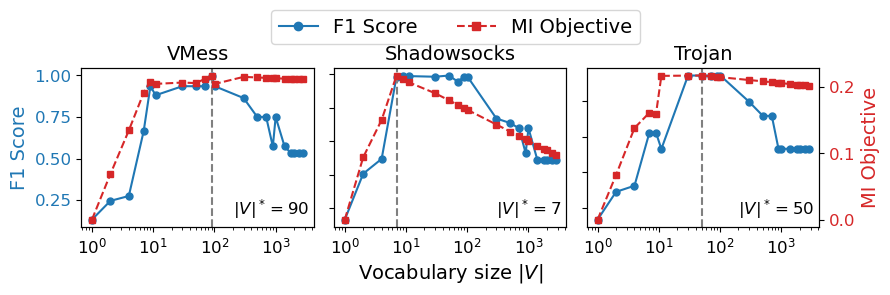

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True)
color_f1 = "tab:blue"
color_obj = "tab:red"

# We'll store the twin axes to access them later if needed
secondary_axes = []

for i, (ax1, protocol) in enumerate(zip(axes, PROTOCOLS)):
    f1_scores = [
        2 * p * r / (p + r) if (p + r) > 0 else 0.0
        for p, r in zip(precision[protocol], recall[protocol])
    ]
    lns1 = ax1.plot(
        VOCABULARY_RANGE,
        f1_scores,
        marker="o",
        markersize=5,
        color=color_f1,
        linestyle="-",
        label="F1 Score",
    )
    ax1.set_xscale("log")
    ax1.axvline(
        vocab_star[protocol],
        color="gray",
        linestyle="--",
        # label=f"|V|*={vocab_star[protocol]}",
    )

    # Only set ylabel and show y-ticks on the left axis of the first subplot
    if i == 0:
        ax1.set_ylabel("F1 Score", color=color_f1, fontsize=14)
        ax1.tick_params(axis="y", labelcolor=color_f1, labelsize=12, left=True, labelleft=True)
    else:
        ax1.set_ylabel("")
        ax1.tick_params(axis="y", labelleft=False, left=False)
    ax1.tick_params(axis="x", labelsize=12)

    ax2 = ax1.twinx()
    secondary_axes.append(ax2)
    lns2 = ax2.plot(
        VOCABULARY_RANGE,
        objective[protocol],
        marker="s",
        markersize=5,
        color=color_obj,
        linestyle="--",
        label="MI Objective",
    )

    # Only set ylabel and show y-ticks on the right axis of the last subplot
    if i == len(axes) - 1:
        ax2.set_ylabel("MI Objective", color=color_obj, fontsize=14)
        ax2.tick_params(axis="y", labelcolor=color_obj, labelsize=12, right=True, labelright=True)
    else:
        ax2.set_ylabel("")
        ax2.tick_params(axis="y", labelright=False, right=False)

    if i == 1:
        ax1.set_xlabel(r"Vocabulary size $|V|$", fontsize=14)

    ax1.set_title(PROTOCOLS_DISPLAY[protocol], fontsize=14)
    ax1.annotate(
        rf"$|V|^*={vocab_star[protocol]}$", 
        xy=(0.98, 0.04), 
        xycoords="axes fraction",
        ha="right", 
        va="bottom", 
        fontsize=12, 
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7)
    )

legend_elems = [
    Line2D([0], [0], color=color_f1, marker="o", linestyle="-", label="F1 Score"),
    Line2D([0], [0], color=color_obj, marker="s", linestyle="--", label="MI Objective"),
    # Line2D([0], [0], color="gray", linestyle="--", label="|V|*"),
]
fig.legend(
    handles=legend_elems,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=14,
)

plt.tight_layout(rect=[0, 0.02, 1, 0.92])
fig.savefig("optimal_vocab_size.pdf", bbox_inches='tight', dpi=300, format='pdf')
plt.show()

In [19]:
flows[6]

array([   40,   -40,    32,   254,   -32, -1432,    32, -1432,  -309,
          32,    32,   125,  -327,  -101,    32])

argmax vocabulary_size = 1


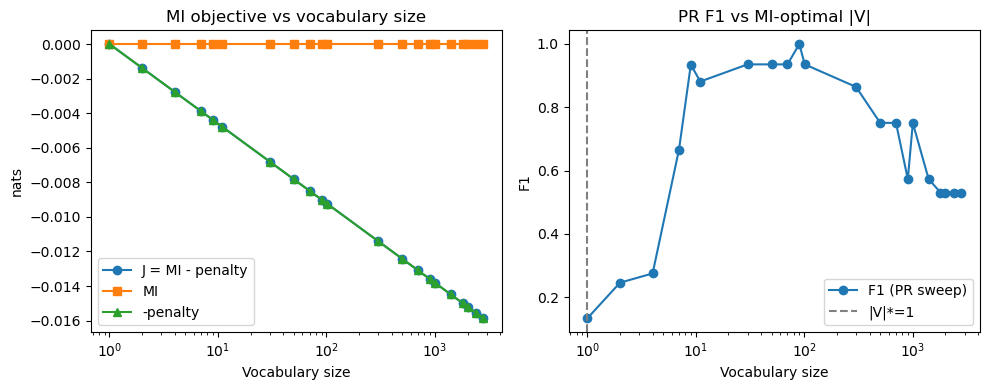

In [12]:

def fit_uniform_binner(v):
    return PacketSizeBinner.fit_uniform(LOWER_BOUND, UPPER_BOUND, v)
rows = sweep_vocabulary_objective(
    flows[:4000],
    STRIP_INDICES,
    WINDOW_SIZE,
    VOCABULARY_RANGE,
    fit_binner=fit_uniform_binner,
    lambda_penalty=0.001,
)
df_obj = pd.DataFrame(rows)
vocab_star = int(df_obj.loc[df_obj["objective"].idxmax(), "vocabulary_size"])
print(f"argmax vocabulary_size = {vocab_star}")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(df_obj["vocabulary_size"], df_obj["objective"], marker="o", label="J = MI - penalty")
axes[0].plot(df_obj["vocabulary_size"], df_obj["mi_nats"], marker="s", label="MI")
axes[0].plot(df_obj["vocabulary_size"], -df_obj["penalty"], marker="^", label="-penalty")
axes[0].set_xscale("log")
axes[0].set_xlabel("Vocabulary size")
axes[0].set_ylabel("nats")
axes[0].legend()
axes[0].set_title("MI objective vs vocabulary size")
f1_scores = [2 * p * r / (p + r) if (p + r) > 0 else 0.0 for p, r in zip(precision[protocol], recall[protocol])]
axes[1].plot(VOCABULARY_RANGE, f1_scores, marker="o", label="F1 (PR sweep)")
axes[1].axvline(vocab_star, color="gray", linestyle="--", label=f"|V|*={vocab_star}")
axes[1].set_xscale("log")
axes[1].set_xlabel("Vocabulary size")
axes[1].set_ylabel("F1")
axes[1].legend()
axes[1].set_title("PR F1 vs MI-optimal |V|")
plt.tight_layout()
plt.show()
